In [1]:
import os
print(os.listdir('data'))

['Advertising.csv', 'auto.csv', 'boston.csv', 'caravan.csv', 'carseats.csv', 'college.csv', 'Credit.csv', 'default.csv', 'hitters.csv', 'khan_xtest.csv', 'khan_xtrain.csv', 'khan_ytest.csv', 'khan_ytrain.csv', 'nci60_data.csv', 'nci60_labs.csv', 'optdigits.tes', 'optdigits.tes.txt', 'optdigits.tra', 'portfolio.csv', 'smarket.csv', 'titanic.csv', 'usarrests.csv', 'wage.csv', 'weekly.csv']


# Chapter 5 Resampling Methods
+ **Resampling** - repeatedly drawing samples from a training set and refitting a modelon each sample - to obtain additional info.

+ Common resampling methods: bootstraping and cross validation. 
+ Cross validation can be used to estimate the test error to evaluate model perfomance (**model assessment**) or to select appropriate level of flexibility (**model selection**).
+ Boostraping provide a measure of accuracy of a parameter estimates or statistical learning method.

## Cross Validation
### Validation Set Approach
+ Usually a test set is not available so a simple strategy to create one is to split the available data into training and testing (**validation or hold-out set**). 
+ Divide the data into half where the observation in each sets are randomly selected.
+ To assess the model perfomance - quantitative responses usually use MSE, for categorical can use error rate, area under the curve, F1 score, weighting of confusion matrix, etc...
+ Drawbacks of this technique: 
    + the validation estimation of the test error rate can be highly variable.
    + the validation set error rate may tend to overestimate the test error rate.



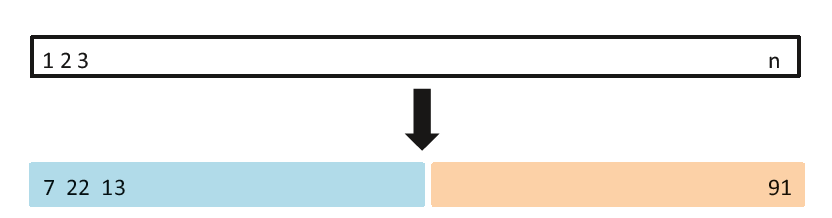

In [2]:
from IPython.display import Image
Image('images/pw41.png', width =500)

#### Example


In [3]:
import pandas as pd
import numpy as np
import sklearn.linear_model as skl_lm
import matplotlib.pyplot as plt
%matplotlib inline


In this section, we'll explore the use of the validation set approach in order to estimate the
test error rates that result from fitting various linear models on the ${\tt Auto}$ data set.

In [5]:
df1 = pd.read_csv('data/auto.csv', na_values='?').dropna()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


We begin by using the ${\tt sample()}$ function to split the set of observations
into two halves, by selecting a random subset of 196 observations out of
the original 392 observations. We refer to these observations as the training
set.

We'll use the ${\tt random\_state}$ parameter in order to set a seed for
${\tt python}$’s random number generator, so that you'll obtain precisely the same results each time. It is generally a good idea to set a random seed when performing an analysis such as cross-validation
that contains an element of randomness, so that the results obtained can be reproduced precisely at a later time.

In [7]:
train_df = df1.sample(196, random_state = 1)
test_df = df1[~df1.isin(train_df)].dropna(how = 'all')

X_train = train_df['horsepower'].values.reshape(-1,1)
y_train = train_df['mpg']
X_test = test_df['horsepower'].values.reshape(-1,1)
y_test = test_df['mpg']

We then use ${\tt LinearRegression()}$ to fit a linear regression to predict ${\tt mpg}$ from ${\tt horsepower}$ using only
the observations corresponding to the training set.

In [9]:
lm = skl_lm.LinearRegression()
model = lm.fit(X_train, y_train)


We now use the ${\tt predict()}$ function to estimate the response for the test
observations, and we use ${\tt sklearn}$ to caclulate the MSE.

In [10]:
pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error

MSE = mean_squared_error(y_test, pred)
    
print(MSE)

23.361902892587224


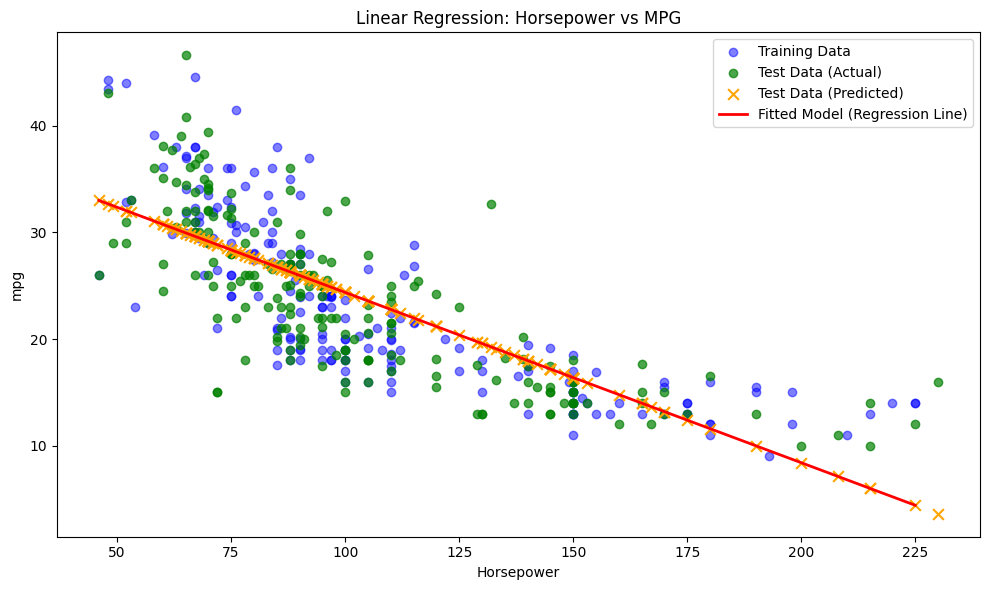

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the plot structure
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot the Training Set (represented as blue dots)
ax.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')

# 3. Plot the Test Set Actual values (represented as green circles)
ax.scatter(X_test, y_test, color='green', alpha=0.7, label='Test Data (Actual)')

# 4. Plot the Test Set Predicted values (represented as orange 'X' markers)
ax.scatter(X_test, pred, color='orange', marker='x', s=60, label='Test Data (Predicted)')

# 5. Plot the Fitted Model (Regression Line)
# We generate a smooth sequence of values from the minimum to the maximum of X_train
X_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
ax.plot(X_line, y_line, color='red', linewidth=2, label='Fitted Model (Regression Line)')

# 6. Add labels, title, and legend
ax.set_xlabel('Horsepower')
ax.set_ylabel('mpg')
ax.set_title('Linear Regression: Horsepower vs MPG')
ax.legend()

# 7. Adjust layout and display the plot
plt.tight_layout()
plt.show()

Therefore, the estimated test MSE for the linear regression fit is 23.36. We
can use the ${\tt PolynomialFeatures()}$ function to estimate the test error for the polynomial
and cubic regressions.

In [16]:
from sklearn.preprocessing import PolynomialFeatures

# Quadratic
poly = PolynomialFeatures(degree=2)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

model = lm.fit(X_train2, y_train)
print(mean_squared_error(y_test, model.predict(X_test2)))

# Cubic
poly = PolynomialFeatures(degree=3)
X_train3 = poly.fit_transform(X_train)
X_test3 = poly.fit_transform(X_test)

model = lm.fit(X_train3, y_train)
print(mean_squared_error(y_test, model.predict(X_test3)))

19.722533470492422
19.92136786007267


These error rates are 20.25 and 20.33, respectively. If we choose a different
training set instead, then we will obtain somewhat different errors on the
validation set. We can test this out by setting a different random seed:

In [17]:
##Choose a different training set

train_df = df1.sample(196, random_state = 2)
test_df = df1[~df1.isin(train_df)].dropna(how = 'all')

X_train = train_df['horsepower'].values.reshape(-1,1)
y_train = train_df['mpg']
X_test = test_df['horsepower'].values.reshape(-1,1)
y_test = test_df['mpg']

# Linear
model = lm.fit(X_train, y_train)
print(mean_squared_error(y_test, model.predict(X_test)))

# Quadratic
poly = PolynomialFeatures(degree=2)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

model = lm.fit(X_train2, y_train)
print(mean_squared_error(y_test, model.predict(X_test2)))

# Cubic
poly = PolynomialFeatures(degree=3)
X_train3 = poly.fit_transform(X_train)
X_test3 = poly.fit_transform(X_test)

model = lm.fit(X_train3, y_train)
print(mean_squared_error(y_test, model.predict(X_test3)))

25.10853905288967
19.722533470492422
19.92136786007267


These results are consistent with our previous findings: a model that
predicts ${\tt mpg}$ using a quadratic function of ${\tt horsepower}$ performs better than
a model that involves only a linear function of ${\tt horsepower}$, and there is
little evidence in favor of a model that uses a cubic function of ${\tt horsepower}$.

### Leave One Out Cross Validation
+ LOOCV has only one observation in the test set and uses all other n-1 observations to build a model. 
+ n different models are built leaving out each observation once and error is averaged over these n trials.  
$$\textrm{CV}_{(n)} = \frac{1}{n}\sum_{i=1}^n{\textrm{MSE}_i}$$
+ LOOCV is better than validation set approach. It has far less bias and tends to not overestimate the test error rate. 
+ Model is built on nearly all the data and there is no randomness in the splits since each observation will be left out once. 
+ It is computationally expensive especially with large n and a complex model.



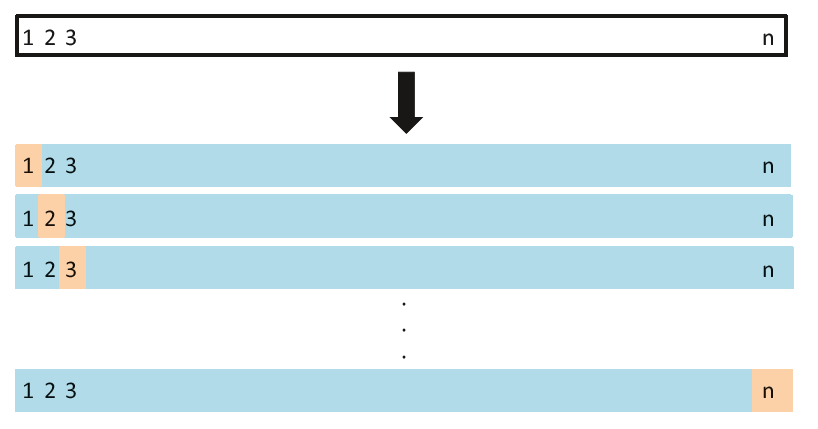

In [18]:
Image('images/pw42.png', width =500)

#### Example

In [20]:
model = lm.fit(X_train, y_train)

from sklearn.model_selection import cross_val_score, LeaveOneOut
loo = LeaveOneOut()
X = df1['horsepower'].values.reshape(-1,1)
y = df1['mpg'].values.reshape(-1,1)
loo.get_n_splits(X)

from sklearn.model_selection import KFold

crossvalidation = KFold(n_splits=392, random_state=None, shuffle=False) #n_split is according to length of data

scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=crossvalidation,
 n_jobs=1)

print("Folds: " + str(len(scores)) + ", MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))


Folds: 392, MSE: 24.231513517929226, STD: 36.79731503640535


We can repeat this procedure for increasingly complex polynomial fits. 

To automate the process, we use the for() function to initiate a for loop which iteratively fits polynomial regressions for polynomials of order i = 1 to i = 5 and computes the associated cross-validation error.

In [21]:
for i in range(1,6):
    poly = PolynomialFeatures(degree=i)
    X_current = poly.fit_transform(X)
    model = lm.fit(X_current, y)
    scores = cross_val_score(model, X_current, y, scoring="neg_mean_squared_error", cv=crossvalidation,
 n_jobs=1)
    
    print("Degree-"+str(i)+" polynomial MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))


Degree-1 polynomial MSE: 24.231513517929226, STD: 36.797315036405344
Degree-2 polynomial MSE: 19.24821312448972, STD: 34.998446151782325
Degree-3 polynomial MSE: 19.33498406405089, STD: 35.76513567786903
Degree-4 polynomial MSE: 19.424430309597113, STD: 35.683352758658955
Degree-5 polynomial MSE: 19.033209965803454, STD: 35.31730131012809


In [23]:
Z = np.array([0,1,2,3,4,5]) #in class addition
Z

array([0, 1, 2, 3, 4, 5])

In [24]:
#Z = [[0,1,2,3,4,5]]
poly = PolynomialFeatures(degree=3)
Z_poly = poly.fit_transform(Z.reshape(-1,1))
print(Z_poly)

[[  1.   0.   0.   0.]
 [  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   3.   9.  27.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]



### k-fold cross validation
+ Similar to LOOCV but this time you leave some number greater than 1 out. 
+ Here, $k$ is the number of partitions of your sample, so if you have $n=1000$ observations and k = 10, the each fold will be 100. 
+ 900 observations would be the training set and 100 observations would act as your test set. 
+ Get an MSE for each fold of these 100 observations and take the average. 
$$\textrm{CV}_{(k)} = \frac{1}{k}\sum_{i=1}^k{\textrm{MSE}_i}$$
+ LOOCV is a special case of k-fold CV whenever $k=n$.
+ Computationally inexpensive compare to LOOCV.
+ Some variability compare to LOOCV.



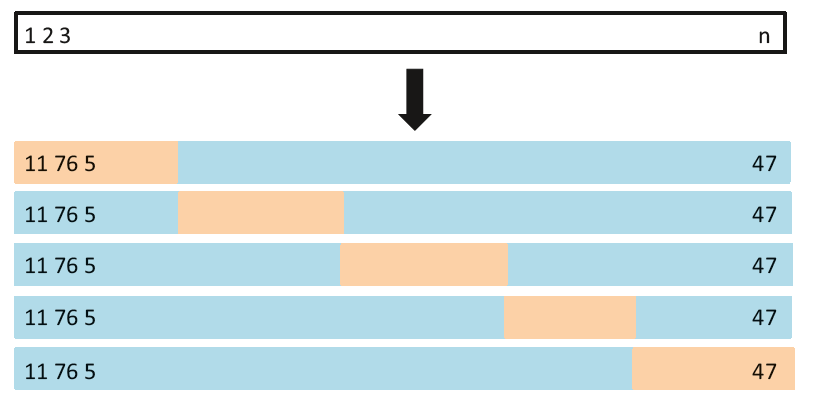

In [42]:
Image('images/pw43.png', width =500)

#### Example

In [43]:
crossvalidation = KFold(n_splits=10, shuffle=False)

for i in range(1,11):
    poly = PolynomialFeatures(degree=i)
    X_current = poly.fit_transform(X)
    model = lm.fit(X_current, y)
    scores = cross_val_score(model, X_current, y, scoring="neg_mean_squared_error", cv=crossvalidation,
 n_jobs=1)
    
    print("Degree-"+str(i)+" polynomial MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Degree-1 polynomial MSE: 27.439933652339864, STD: 14.510250711281135
Degree-2 polynomial MSE: 21.235840055801585, STD: 11.797327528897467
Degree-3 polynomial MSE: 21.336606183331117, STD: 11.844339714581873
Degree-4 polynomial MSE: 21.353886976174397, STD: 11.986332284638403
Degree-5 polynomial MSE: 20.905558642375237, STD: 12.185448360778402
Degree-6 polynomial MSE: 21.083872156970877, STD: 12.133892968646666
Degree-7 polynomial MSE: 21.07449657465541, STD: 12.005506101346047
Degree-8 polynomial MSE: 20.96380634549775, STD: 11.941080559106963
Degree-9 polynomial MSE: 21.13330080918903, STD: 12.123884461516864
Degree-10 polynomial MSE: 21.917210792191774, STD: 12.620015985973138


### bias-variance tradeoff between LOOCV and k-folds
+ Since LOOCV trains on nearly all the data, the test error rate will generally be lower than k-fold and therefore less biased. 
+ LOOCV will have higher variance since all $n$ models will be very highly correlated to one another. 
+ Since the models won't differ much, the test error rate (which what CV is measuring) will vary more than k-fold which has fewer models that are less correlated with one another. 
+ A value of $k$ between 5 and 10 is a good rule of thumb that balances the trade-off between bias and variance

#### Example: Default Data

In [25]:
df2 = pd.read_csv('data/default.csv', na_values='?').dropna()
df2.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


In [26]:
df2.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


First we'll try just holding out a random 20% of the data:

In [27]:
import statsmodels.formula.api as smf  #abaikan
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, classification_report

for i in range(1,11):
    train_df2 = df2.sample(8000, random_state = i)
    test_df2 = df2[~df2.isin(train_df2)].dropna(how = 'all')
    
    # Fit a logistic regression to predict default using balance
    model = smf.glm('default~balance', data=train_df2, family=sm.families.Binomial())
    result = model.fit()
    predictions_nominal = [ "Yes" if x < 0.5 else "No" for x in result.predict(test_df2)]
    print("----------------")
    print("Random Seed = " + str(i) + "")
    print("----------------")
    print(confusion_matrix(test_df2["default"], 
                       predictions_nominal))
    print(classification_report(test_df2["default"], 
                            predictions_nominal, 
                            digits = 3))
    print()
    

----------------
Random Seed = 1
----------------
[[1921    6]
 [  50   23]]
              precision    recall  f1-score   support

          No      0.975     0.997     0.986      1927
         Yes      0.793     0.315     0.451        73

    accuracy                          0.972      2000
   macro avg      0.884     0.656     0.718      2000
weighted avg      0.968     0.972     0.966      2000


----------------
Random Seed = 2
----------------
[[1919   13]
 [  47   21]]
              precision    recall  f1-score   support

          No      0.976     0.993     0.985      1932
         Yes      0.618     0.309     0.412        68

    accuracy                          0.970      2000
   macro avg      0.797     0.651     0.698      2000
weighted avg      0.964     0.970     0.965      2000


----------------
Random Seed = 3
----------------
[[1918   14]
 [  49   19]]
              precision    recall  f1-score   support

          No      0.975     0.993     0.984      1932
    

### Precision Score
The precision is intuitively the ability of the classifier not to label as positive a sample that is negative.
TP – True Positives
FP – False Positives

Precision – Accuracy of positive predictions.
Precision = TP/(TP + FP)

### Recall Score
The recall is intuitively the ability of the classifier to find all the positive samples.
FN – False Negatives

Recall (aka sensitivity or true positive rate): Fraction of positives That were correctly identified.
Recall = TP/(TP+FN)

### F1 Score
F1 Score (aka F-Score or F-Measure) – A helpful metric for comparing two classifiers. F1 Score takes into account precision and the recall. It is created by finding the the harmonic mean of precision and recall.

F1 = 2 x (precision x recall)/(precision + recall)

The F1 score reaches its best value at 1 and worst score at 0.

The F1 score weights recall more than precision by a factor of beta. beta == 1.0 means recall and precision are equally important.

### Support
The support is the number of occurrences of each class in y_true.



# Exercise 

Build a logistic model on the full Default dataset and then run 5-fold cross-validation to get a more accurate estimate of your test error rate:

In [47]:
?np.ones


Signature: np.ones(shape, dtype=None, order='C', *, device=None, like=None)
Docstring:
Return a new array of given shape and type, filled with ones.

Parameters
----------
shape : int or sequence of ints
    Shape of the new array, e.g., ``(2, 3)`` or ``2``.
dtype : data-type, optional
    The desired data-type for the array, e.g., `numpy.int8`.  Default is
    `numpy.float64`.
order : {'C', 'F'}, optional, default: C
    Whether to store multi-dimensional data in row-major
    (C-style) or column-major (Fortran-style) order in
    memory.
device : str, optional
    The device on which to place the created array. Default: None.
    For Array-API interoperability only, so must be ``"cpu"`` if passed.

    .. versionadded:: 2.0.0
like : array_like, optional
    Reference object to allow the creation of arrays which are not
    NumPy arrays. If an array-like passed in as ``like`` supports
    the ``__array_function__`` protocol, the result will be defined
    by it. In this case, it ensur

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn import metrics

df2 = pd.read_csv('data/default.csv', na_values='?').dropna()

df2['Yes'] = (df2['default'] == 'Yes').astype(int)

X = np.column_stack((np.ones(len(df2)), df2['balance']))
y=df2['Yes'].values

lr=LogisticRegression()
predicted = cross_val_predict(lr, X, y, cv=5)
print(metrics.accuracy_score(y, predicted))

print("---------------------------------------------")
# Generate the raw confusion matrix array
cm = confusion_matrix(y, predicted)
cm_df = pd.DataFrame(cm, 
                     index=['Actual 0', 'Actual 1'], 
                     columns=['Predicted 0', 'Predicted 1'])
print(cm_df)
print("---------------------------------------------")

print(metrics.classification_report(y, predicted)) 


0.9725
---------------------------------------------
          Predicted 0  Predicted 1
Actual 0         9624           43
Actual 1          232          101
---------------------------------------------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9667
           1       0.70      0.30      0.42       333

    accuracy                           0.97     10000
   macro avg       0.84      0.65      0.70     10000
weighted avg       0.97      0.97      0.97     10000



In [36]:
#Class 0 Precision 
101/(101+43)


0.7013888888888888

In [ ]:
#Class 0 Recall




Class 0 (No default)
+ Precision (0.98): When the model predicts that a customer will not default, it is correct 98% of the time.
+ Recall (1.00): Out of all the people in the dataset who actually didn't default, the model successfully identified 100% of them (9,624 out of 9,667).
+ F1-Score (0.99): The harmonic mean of precision and recall for this class. A score of 0.99 indicates near-perfect classification performance for non-defaulters.
+ Support (9,667): The actual number of rows in your test dataset that belong to Class 0.

Class 1 (default)
+ Precision (0.70): When the model actively flags a customer as a "Defaulter," it is only correct 70% of the time (101 out of 144 times it guessed "Default").
+ Recall (0.30): The model only managed to catch 30% of the actual defaulters. It let 70% of them (232 people) slip through undetected.
+ F1-Score (0.42): Because the recall is so low, the F1-score drops to 0.42, mathematically proving that the model is weak at tracking down loan defaults.
+ Support (333): The actual number of rows in your test dataset that belong to Class 1.

<br>
__| Pred 0,  Pred 1 |<br>
Actual 0 | TN, FP |<br>
Actual 1 | FN, TP |<br>
TP (True Positive): Predicted Default, Actually Default (101)<br>
TN (True Negative): Predicted No Default, Actually No Default (9,624)<br>
FP (False Positive): Predicted Default, Actually No Default (43)<br>
FN (False Negative): Predicted No Default, Actually Default (232)<br>


---

## 1. Accuracy
Measures the overall proportion of correct predictions (both true positives and true negatives) out of all total evaluations.

$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

Accuracy is a highly intuitive metric, but it can be extremely misleading when dealing with **imbalanced datasets** (e.g., when 97% of your data belongs to one class).

---

## 2. Precision
Measures the reliability or quality of the model's positive predictions. It answers the question: *Of all the cases the model flagged as positive, how many were actually positive?*

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

A high precision score means that when the model predicts a positive outcome, you can trust it. This metric is prioritized when the cost of a False Positive is high (e.g., flagging an innocent email as spam).

---

## 3. Recall (Sensitivity / True Positive Rate)
Measures the model's ability to find and capture all actual positive cases. It answers the question: *Of all the actual positive cases present in the dataset, how many did the model manage to catch?*

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

A high recall score means the model leaves very few positive cases behind. This metric is prioritized when missing a positive case is highly detrimental or dangerous (e.g., catching a fraudulent bank transaction or diagnosing a life-threatening illness).

---

## 4. F1-Score
The **harmonic mean** of Precision and Recall. It provides a single, balanced metric that scores the model's performance across both dimensions.

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

*Alternatively expressed using the raw confusion matrix counts:*
$$\text{F1-Score} = \frac{2\text{TP}}{2\text{TP} + \text{FP} + \text{FN}}$$

The F1-Score is mathematically structured to heavily penalize models that suffer from an extreme imbalance between Precision and Recall. It is the go-to metric when you need a balance between quality (Precision) and quantity (Recall), especially on imbalanced datasets.

In [29]:
#accuracy of positive prediction = prediction
(9624)/(9624+101)

0.9896143958868895

In [30]:
#Recall class 0
9624/(9624+43)

0.9955518775214648

In [31]:
#Recall class 1 TP/(TP+FN)
101/(232+101)

0.3033033033033033

# Bootstrap
+ Can be used to quantify the uncertainty associated with a given estimator or statistical learning method.
+ Bootstrap approach allows us to use a computer to emulate the process of obtaining new sample sets, to estimate the variability of estimated parameter without generating additional samples.
+ Rather than repeatedly obtaining independent data sets from the population, we instead obtain distinct data sets by repeatedly sampling observations from the original data set.
+ We randomly select $n$ observations from the data set in order to produce a bootstrap data set.
+ The sampling is performed with replacement, which means that the same observation can occur more than once in the bootstrap data set.




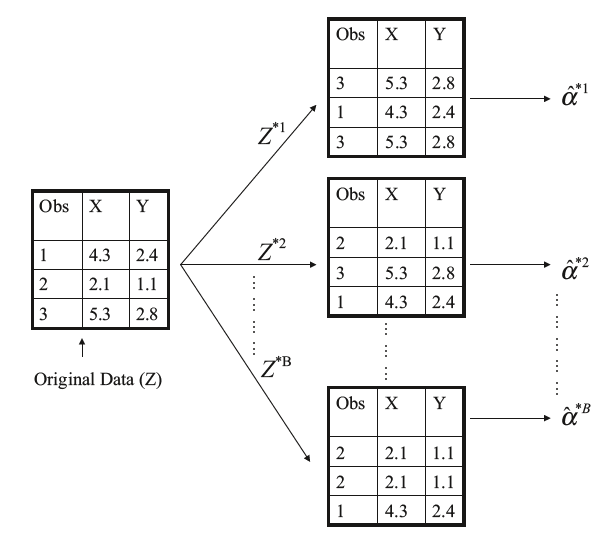

In [59]:
Image('images/pw44.png', width =500)

#### Example:
+ Suppose that we wish to invest a fixed sum of money in two financial assets that yield returns of $X$ and $Y$ , respectively, where $X$ and $Y$ are random quantities. 
+ We will invest a fraction $\alpha$ of our money in $X$, and the remaining $1 − \alpha$ in $Y$. 
+ Since there is variability associated with the returns on these two assets, we wish to choose $\alpha$ to minimize the total risk, or variance, of our investment.
$$\hat{\alpha} = \frac{\hat{\sigma}^2_Y - \hat{\sigma}_{XY}}{\hat{\sigma}^2_X + \hat{\sigma}^2_Y - 2\hat{\sigma}_{XY}}$$
+ 100 pairs of returns for the investments $X$ and $Y$ are simulated, to estimate $\hat{\sigma}^2_X, \hat{\sigma}^2_Y$ and $\hat{\sigma}_{XY}$, to obtain $\hat{\alpha}$.
+ This process is repeated 1000 times, resulting 1000 estimates for $\alpha$.
+ $0.532 \leq \hat{\alpha} \leq 0.657$.
+ $\bar{\alpha} = 0.5996$ and $\textrm{SE}(\hat{\alpha}) = 0.083$.
+ However this cannot be applied, because for real data we cannot generate new samples from the original population. 
+ By using bootstrap technique,we can resample the data repeatedly.
+ The bootstrap data set, $Z^{*i}$ can be used to produce the estimate for $\alpha$, given as $\hat{\alpha}^{*i}$.
+ The SE of this bootstrap estimates is
$$\textrm{SE}_B(\hat{\alpha}) = \sqrt{\frac{1}{B-1}\sum_{r=1}^B{\left( \hat{\alpha}^{*r} - \frac{1}{B} \sum_{r^\prime = 1}^B{\hat{\alpha}^{*r^\prime}}\right)^2}}$$


#### Example

In [ ]:
portfolio_df = pd.read_csv('data/portfolio.csv')
portfolio_df.head()

,Unnamed: 0,X,Y
0,1,-0.895251,-0.234924
1,2,-1.562454,-0.885176
2,3,-0.417090,0.271888
3,4,1.044356,-0.734198
4,5,-0.315568,0.841983


In [ ]:
portfolio_df.shape

(100, 3)

To illustrate the use of the bootstrap on this data, we must first create
a function, `alpha()`, which takes as input the data and outputs the estimate for $\alpha$ (described in more detail on page 187).

In [ ]:
def alpha(X,Y):
    return ((np.var(Y)-np.cov(X,Y))/(np.var(X)+np.var(Y)-2*np.cov(X,Y)))

This function returns, or outputs, an estimate for $\alpha$ based on applying
(5.7) to the observations indexed by the argument index. For instance, the
following command tells `python` to estimate $\alpha$ using all 100 observations.

In [64]:
X = portfolio_df.X[0:100]
y = portfolio_df.Y[0:100]
print(alpha(X,y))

[[1.07270947 0.57665115]
 [0.57665115 0.06414064]]


The next command uses the `sample()` function to randomly select 100 observations
from the range 1 to 100, with replacement. This is equivalent
to constructing a new bootstrap data set and recomputing $\hat{\alpha}$ based on the
new data set.

In [74]:
dfsample = portfolio_df.sample(frac=1, replace=True)
X = dfsample.X[0:100]
y = dfsample.Y[0:100]
print(alpha(X,y))

[[2.54371206 0.51433958]
 [0.51433958 0.21839698]]


**sklearn have deprecated bootstrap function because the ML community does not seen resampling as crucial or useful**

We can implement a bootstrap analysis by performing this command many
times, recording all of the corresponding estimates for $\alpha$, and computing the resulting standard deviation. Below we produce $1,000$ bootstrap estimates for $\alpha$:

In [75]:
def bstrap(df):
    tresult = 0
    for i in range(0,1000):
        dfsample = df.sample(frac=1, replace=True)
        X = dfsample.X[0:100]
        y = dfsample.Y[0:100]
        result = alpha(X,y)
        tresult += result
    fresult = tresult / 1000
    print(fresult)
    
bstrap(portfolio_df)

[[1.33354753 0.58040197]
 [0.58040197 0.17946886]]


The final output shows that using the original data, $\hat{\alpha} = 0.58$

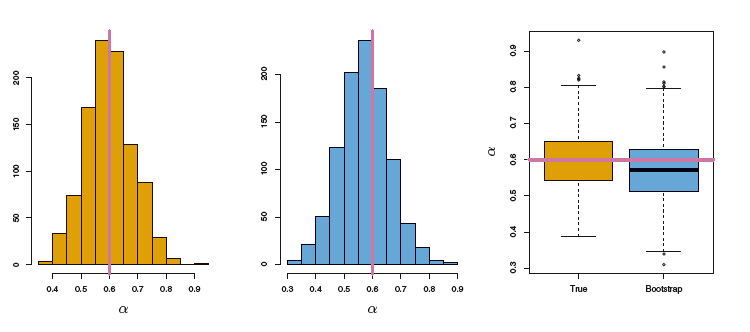

In [76]:
Image('images/pw45.png', width =800)

Left: A Histogram of the estimates of $\alpha$ obtained by generating 1,000 simulated data sets from the true population. 

Center: A histogram of the estimates of $\alpha$ obtained from 1,000 bootstrap samples from a single data set.

Right: The estimates of $\alpha$ displayed in the left and center panels are shown as boxplots. 

In each panel, the pink line indicates the true value of α.

#### Example
The bootstrap approach can be used to assess the variability of the coefficient
estimates and predictions from a statistical learning method. 

Here we use the bootstrap approach in order to assess the variability of the
estimates for $\beta_0$ and $\beta_1$, the intercept and slope terms for the linear regression
model that uses horsepower to predict mpg in the Auto data set.

We will compare the estimates obtained using the bootstrap to those obtained
using the formulas for $SE(\hat{\beta}_0)$ and $SE(\hat{\beta}_1)$ described in Section 3.1.2.



In [77]:
from sklearn.utils import resample

auto_df = pd.read_csv('data/auto.csv')

auto_df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [78]:
lm = skl_lm.LinearRegression()
X = auto_df['horsepower'].values.reshape(-1,1)
y = auto_df['mpg']
clf = lm.fit(X,y)
print(clf.coef_, clf.intercept_)

[-0.15784473] 39.93586102117047


In [ ]:
from sklearn.metrics import mean_squared_error #this is just resampling, use for loop and average for bootstrap

Xsamp, ysamp = resample(X, y, n_samples=1000)
clf = lm.fit(Xsamp,ysamp)
print('Intercept: ' + str(clf.intercept_) + " Coef: " + str(clf.coef_))

Intercept: 39.48413673362434 Coef: [-0.15392359]


# Exercise 5

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

In [ ]:
default = pd.read_csv('data/default.csv')
default['student_yes'] = (default['student'] == 'Yes').astype('int')
default['default_yes'] = (default['default'] == 'Yes').astype('int')

In [ ]:
default.head()

In [ ]:
X = default[['balance', 'income']]
y = default['default_yes']

# No Validation set

### Sklearn

In [ ]:
# Notice how tol must be changed to less than default value or convergence won't happen
# Use a high value of C to remove regularization
model = LogisticRegression(C=100000, tol=.0000001)
model.fit(X, y)
model.intercept_, model.coef_

### Statsmodels
Coefficients are similar

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
result = smf.logit(formula='default_yes ~ balance + income', data=default).fit()

In [ ]:
smf.logit?

In [ ]:
result.summary()

### Error without validation set
This is an in-sample prediction. Training error in both sklearn and statsmodels. Both are equivalent

In [ ]:
(model.predict(X) == y).mean()

In [ ]:
((result.predict(X) > .5) * 1 == y).mean()

## With validation set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
model = LogisticRegression(C=100000, tol=.0000001)
model.fit(X_train, y_train)
model.intercept_, model.coef_

In [ ]:
X_train_sm = X_train.join(y_train)

In [ ]:
result = smf.logit(formula='default_yes ~ balance + income', data=X_train_sm).fit()
result.summary()

In [ ]:
result.fit?

In [ ]:
# Nearly the same as training set. So not too much over fitting has happened
(model.predict(X_test) == y_test).mean(), ((result.predict(X_test) > .5) * 1 == y_test).mean()

Validation error of only .0272

In [ ]:
# c) repeat for 3 different validation sets
model = LogisticRegression(C=100000, tol=.0000001)

for i in range(3):
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model.fit(X_train, y_train)
    
    X_train_sm = X_train.join(y_train)
    result = smf.logit(formula='default_yes ~ balance + income', data=X_train_sm).fit()
    print((model.predict(X_test) == y_test).mean(), ((result.predict(X_test) > .5) * 1 == y_test).mean())

In [ ]:
# d) include student in model
X = default[['balance', 'income', 'student_yes']]
y = default['default_yes']

model = LogisticRegression(C=100000, tol=.0000001)

for i in range(3):
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model.fit(X_train, y_train)
    
    X_train_sm = X_train.join(y_train)
    result = smf.logit(formula='default_yes ~ balance + income + student_yes', data=X_train_sm).fit()
    print((model.predict(X_test) == y_test).mean(), ((result.predict(X_test) > .5) * 1 == y_test).mean())

Looks like error rate is very similar

## Exercise 6
Computing stand errors of coefficents of logistic regression using bootstrap

In [ ]:
result = smf.logit(formula='default_yes ~ balance + income', data=default).fit()
result.summary()

In [ ]:
df_params = pd.DataFrame(columns=['Intercept', 'balance', 'income'])
for i in range(100):
    default_sample = default.sample(len(default), replace=True)
    result_sample = smf.logit(formula='default_yes ~ balance + income', data=default_sample).fit(disp=0)
    df_params = pd.concat([df_params, pd.DataFrame([result_sample.params])], ignore_index=True)


In [ ]:
# bootstrap parameters and standard error
df_params.mean(), df_params.std()

In [ ]:
# model parameters and standard error
result.params, result.bse

Standard errors are a wee bit higher in bootstrap

# 7
a) Fit Logistic Regression with Lag1, Lag2

In [ ]:
weekly = pd.read_csv('data/weekly.csv')

In [ ]:
weekly['Direction_Up'] = (weekly['Direction'] == 'Up').astype(int)

In [ ]:
weekly.head()

In [ ]:
X = weekly[['Lag1', 'Lag2']]
y = weekly['Direction_Up']

In [ ]:
model = LogisticRegression(C=100000, tol=.0000001)
model.fit(X, y)

In [ ]:
model.intercept_, model.coef_

In [ ]:
# accuracy
(model.predict(X) == y).mean()

### b) Fit without first observation

In [ ]:
# model is different but nearly identical
model.fit(X.iloc[1:], y.iloc[1:])
model.intercept_, model.coef_, (model.predict(X) == y).mean()

In [ ]:
# c
# wrong prediction
model.predict([X.iloc[0]]), y[0]

In [ ]:
# d
errors = np.zeros(len(X))
for i in range(len(X)):
    leave_out  = ~X.index.isin([i])
    model.fit(X[leave_out], y[leave_out])
    if model.predict([X.iloc[i]]) != y[i]:
        errors[i] = 1

In [ ]:
# e
errors.mean()

# 8

In [ ]:
np.random.seed(1)
x = np.random.randn(100)
e = np.random.randn(100)
y = x - 2*x**2 + e

In [ ]:
y.shape

In [ ]:
plt.scatter(x, y);

In [ ]:
df = pd.DataFrame(np.array([np.ones(len(x)), x, x ** 2, x ** 3, x ** 4, y]).T, columns=['b0', 'x', 'x2', 'x3', 'x4', 'y'])
df.head()

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
X = df.iloc[:, :5]
y = df['y']
model = LinearRegression()
errors = np.zeros((len(X), 4))
for i in range(len(X)):
    leave_out  = ~X.index.isin([i])
    for j in range(4):
        model.fit(X.iloc[leave_out, :j+2], y[leave_out])
        errors[i, j] = (model.predict([X.iloc[i, :j+2]]) - y[i]) ** 2

In [ ]:
# each error here is average error for linear, quadratic, cubic and quartic model.
# Looks like it stabilizes at quadratic.
errors.mean(axis=0)

In [ ]:
# again with different seed. 
np.random.seed(2)
x = np.random.randn(100)
e = np.random.randn(100)
y = x - 2*x**2 + e
df = pd.DataFrame(np.array([np.ones(len(x)), x, x ** 2, x ** 3, x ** 4, y]).T, columns=['b0', 'x', 'x2', 'x3', 'x4', 'y'])


X = df.iloc[:, :5]
y = df['y']
model = LinearRegression()
errors = np.zeros((len(X), 4))
for i in range(len(X)):
    leave_out  = ~X.index.isin([i])
    for j in range(4):
        model.fit(X.iloc[leave_out, :j+2], y[leave_out])
        errors[i, j] = (model.predict([X.iloc[i, :j+2]]) - y[i]) ** 2

# quite a different average error. But again stabilizes at quadratic which makes sense
errors.mean(axis=0)

### f 
since the error doesn't improve after quadratic it's likely the 
standard errors for x3 and x4 would not be significant

# 9

In [ ]:
boston = pd.read_csv('data/boston.csv')
boston.head()

In [ ]:
#a
boston['medv'].mean()

In [ ]:
#b 
# standard deviation of mean
boston['medv'].std() / np.sqrt(len(boston))

In [ ]:
#c
#bootstrap standard deviation of mean
means = [boston['medv'].sample(n = len(boston), replace=True).mean() for i in range(1000)]
np.std(means)

In [ ]:
#d
se = np.std(means)
boston['medv'].mean() - 2 * se, boston['medv'].mean() + 2 * se

http://stackoverflow.com/questions/15033511/compute-a-confidence-interval-from-sample-data

In [ ]:
import scipy.stats as st

In [ ]:
st.t.interval(0.95, len(boston['medv'])-1, loc=np.mean(boston['medv']), scale=st.sem(boston['medv']))

In [ ]:
#e
boston['medv'].median()

In [ ]:
#f
medians = [boston['medv'].sample(n = len(boston), replace=True).median() for i in range(1000)]
np.std(medians)

In [ ]:
#g
boston['medv'].quantile(.1)

In [ ]:
#h
quantile_10 = [boston['medv'].sample(n = len(boston), replace=True).quantile(.1) for i in range(1000)]
np.std(quantile_10)